# 02 — Forecast Model Fitting

## Purpose
This notebook fits baseline forecasting models to each simulated dataset and evaluates basic model diagnostics.

## Outputs
- Fitted VAR models
- Fitted RNN/DeepAR models
- Stability diagnostics
- Mean forecast comparisons

## Future Work
- Tune RNN architecture and training configuration
- Explore additional forecasting baselines

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.seeds import set_seed
from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import load_array_npz, save_array_npz, save_table, save_json, save_current_figure
from src.api.modeling import fit_model, fit_var_experiments
from src.vector_ar.stability import stability_summary
from src.vector_ar.forecast import forecast_var_mean

set_seed(123)

config = ExperimentConfig()
dgp_names = config.dgp_names
lags = config.lags
n_train = config.n_train
n_test = 100

dirs = result_dirs("02_var_deepar_fit",test=False,)
simulated_dir = ROOT / "data" / "simulated"
datasets = {}

for name in dgp_names:
    path = simulated_dir / f"{name}_var_dgp.npz"
    data = load_array_npz(path)
    y = data["y"]
    y_train = y[:n_train]
    y_test = y[n_train:n_train + n_test]
    datasets[name] = {
        "y": y,
        "y_train": y_train,
        "y_test": y_test,
        "innovations": data["innovations"],
        "A": data["A"],
        "Sigma": data["Sigma"],
    }

    print(
        name,
        "y:",y.shape,
        "train:",y_train.shape,
        "test:",y_test.shape,
    )

gaussian y: (800, 3) train: (600, 3) test: (100, 3)
student_t y: (800, 3) train: (600, 3) test: (100, 3)
mixture y: (800, 3) train: (600, 3) test: (100, 3)
heteroskedastic y: (800, 3) train: (600, 3) test: (100, 3)


## VAR Fitting

Each DGP is fitted using the same VAR specification. The goal is to keep the forecasting backbone fixed so that later differences in forecast calibration can be attributed primarily to innovation modeling choices.

In [2]:
var_fits, fit_summary_df = fit_var_experiments(
    datasets=datasets,
    lags=lags,
    output_dir=dirs["models"],
)

save_table(
    fit_summary_df,
    dirs["tables"] / "var_fit_summary.csv",
)

fit_summary_df

/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


,dgp,model,lags,n_train,n_test,stable,max_modulus,resid_mean_abs,resid_avg_std
0,gaussian,VAR,1,600,100,True,0.478508,1.145130e-16,1.015502
1,student_t,VAR,1,600,100,True,0.447533,8.643306e-17,1.424089
2,mixture,VAR,1,600,100,True,0.451608,5.486244e-17,1.441238
3,heteroskedastic,VAR,1,600,100,True,0.401363,4.349455e-17,1.828823


In [3]:
from src.api.modeling import generate_var_mean_forecasts
horizon = config.horizon

mean_forecasts = generate_var_mean_forecasts(
    datasets=datasets,
    var_fits=var_fits,
    lags=lags,
    horizon=horizon,
    output_dir=dirs["models"],
)

for name, forecast in mean_forecasts.items():
    print(
        name,
        forecast.shape,
    )

gaussian (40, 3)
student_t (40, 3)
mixture (40, 3)
heteroskedastic (40, 3)


Saved: var_mean_forecasts.png


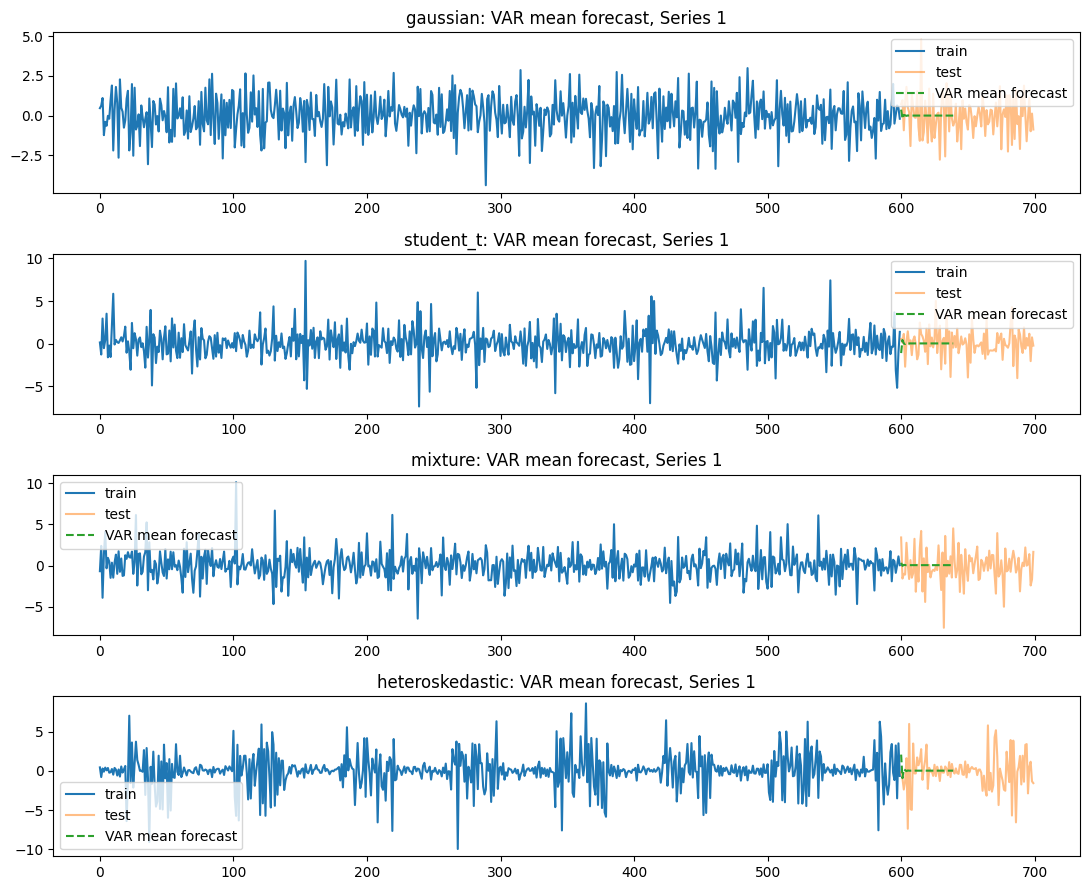

In [4]:
from src.plots.modeling import plot_mean_forecasts

plot_mean_forecasts(
    datasets=datasets,
    forecasts=mean_forecasts,
    dgp_names=dgp_names,
    horizon=horizon,
    forecast_label="VAR mean forecast",
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_mean_forecasts.png"
)

print(
    "Saved: var_mean_forecasts.png"
)

# Probabilistic "in the style of" DeepAR Forecaster

In [5]:
from src.utils.device import get_device
from src.api.modeling import fit_model

# RNN / DeepAR-style probabilistic forecaster configuration
rnn_context_length = 40
rnn_prediction_length = horizon
rnn_hidden_dim = 64
rnn_num_layers = 1
rnn_dropout = 0.0
rnn_batch_size = 32
rnn_epochs = 100
rnn_lr = 1e-3
rnn_device = get_device()

print("RNN device:", rnn_device)

RNN device: mps


In [6]:
from src.api.modeling import fit_rnn_experiments

rnn_fits, rnn_fit_summary_df = fit_rnn_experiments(
    datasets=datasets,
    output_dir=dirs["models"],
    context_length=rnn_context_length,
    prediction_length=rnn_prediction_length,
    hidden_dim=rnn_hidden_dim,
    num_layers=rnn_num_layers,
    dropout=rnn_dropout,
    batch_size=rnn_batch_size,
    epochs=rnn_epochs,
    lr=rnn_lr,
    device=rnn_device,
)

save_table(
    rnn_fit_summary_df,
    dirs["tables"] / "rnn_fit_summary.csv",
)

rnn_fit_summary_df


Fitting RNN for: gaussian


Epoch 0001 | loss = 1.895445
Epoch 0010 | loss = 1.555793
Epoch 0020 | loss = 1.550367
Epoch 0030 | loss = 1.544281
Epoch 0040 | loss = 1.538197
Epoch 0050 | loss = 1.522167
Epoch 0060 | loss = 1.485975
Epoch 0070 | loss = 1.452582
Epoch 0080 | loss = 1.420252
Epoch 0090 | loss = 1.391551
Epoch 0100 | loss = 1.364815

Fitting RNN for: student_t
Epoch 0001 | loss = 3.123343
Epoch 0010 | loss = 1.869188
Epoch 0020 | loss = 1.866005
Epoch 0030 | loss = 1.847650
Epoch 0040 | loss = 1.834574
Epoch 0050 | loss = 1.818108
Epoch 0060 | loss = 1.791501
Epoch 0070 | loss = 1.766435
Epoch 0080 | loss = 1.751853
Epoch 0090 | loss = 1.734567
Epoch 0100 | loss = 1.708647

Fitting RNN for: mixture
Epoch 0001 | loss = 3.179224
Epoch 0010 | loss = 1.907300
Epoch 0020 | loss = 1.899100
Epoch 0030 | loss = 1.893394
Epoch 0040 | loss = 1.882297
Epoch 0050 | loss = 1.868716
Epoch 0060 | loss = 1.854277
Epoch 0070 | loss = 1.834632
Epoch 0080 | loss = 1.810577
Epoch 0090 | loss = 1.785161
Epoch 0100 | loss 

,dgp,model,context_length,prediction_length,hidden_dim,num_layers,epochs,final_loss
0,gaussian,RNN,40,40,64,1,100,1.364815
1,student_t,RNN,40,40,64,1,100,1.708647
2,mixture,RNN,40,40,64,1,100,1.753731
3,heteroskedastic,RNN,40,40,64,1,100,1.473265


In [7]:
from src.api.forecasts import generate_rnn_forecast_experiments

rnn_forecasts = generate_rnn_forecast_experiments(
    datasets=datasets,
    rnn_fits=rnn_fits,
    prediction_length=rnn_prediction_length,
    n_paths=config.n_paths,
    seed=config.seed,
    output_dir=dirs["forecasts"],
)


Generating RNN forecasts for: gaussian
gaussian (250, 40, 3) (40, 3)

Generating RNN forecasts for: student_t
student_t (250, 40, 3) (40, 3)

Generating RNN forecasts for: mixture
mixture (250, 40, 3) (40, 3)

Generating RNN forecasts for: heteroskedastic
heteroskedastic (250, 40, 3) (40, 3)


Saved: rnn_mean_forecasts.png


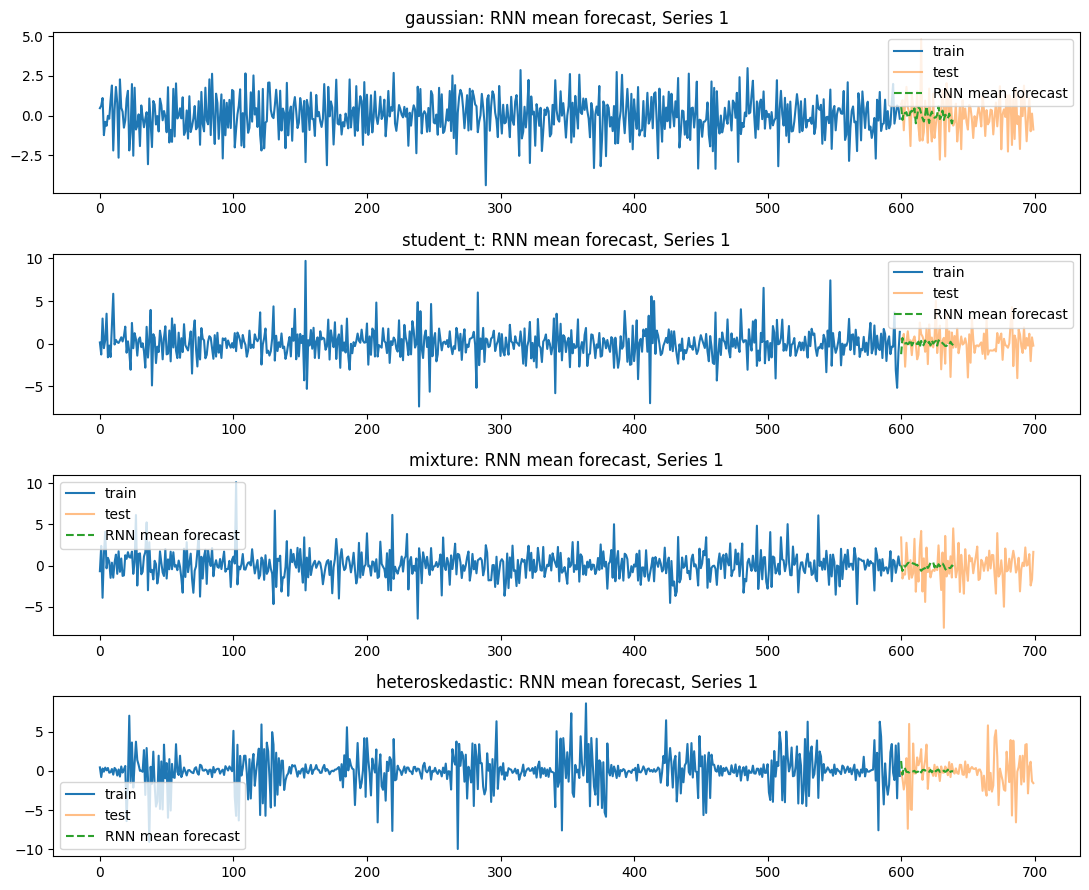

In [8]:
rnn_mean_forecasts = {
    name: forecast["predictive_mean"]
    for name, forecast in rnn_forecasts.items()
}

plot_mean_forecasts(
    datasets=datasets,
    forecasts=rnn_mean_forecasts,
    dgp_names=dgp_names,
    horizon=rnn_prediction_length,
    forecast_label="RNN mean forecast",
    variable=0,
)

save_current_figure(
    dirs["figures"] / "rnn_mean_forecasts.png"
)

print(
    "Saved: rnn_mean_forecasts.png"
)

Saved: rnn_training_loss.png


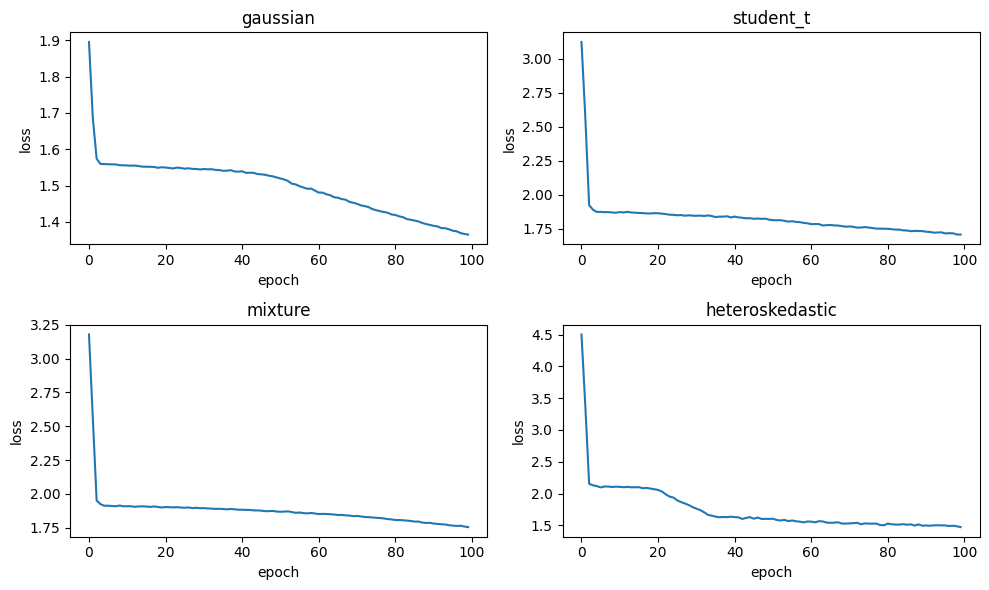

In [9]:
from src.plots.modeling import plot_rnn_training_loss
plot_rnn_training_loss(
    rnn_fits=rnn_fits,
    dgp_names=dgp_names,
)

save_current_figure(
    dirs["figures"] / "rnn_training_loss.png"
)

print(
    "Saved: rnn_training_loss.png"
)

In [10]:
for name in dgp_names:

    forecast = rnn_forecasts[name]

    scale = forecast["predictive_scale"]

    print(
        name,
        "mean scale:",
        scale.mean(),
        "max scale:",
        scale.max(),
    )

gaussian mean scale: 1.053835 max scale: 1.853438
student_t mean scale: 1.4352913 max scale: 2.097994
mixture mean scale: 1.6034023 max scale: 2.6244845
heteroskedastic mean scale: 1.5275561 max scale: 3.505532


In [11]:
from src.api.modeling import compare_mean_forecasts
mean_forecast_comparison_df = compare_mean_forecasts(
    datasets=datasets,
    mean_forecasts=mean_forecasts,
    rnn_forecasts=rnn_forecasts,
    horizon=horizon,
)

save_table(
    mean_forecast_comparison_df,
    dirs["tables"] / "var_rnn_mean_forecast_comparison.csv",
)

mean_forecast_comparison_df

,dgp,var_mean_mse,rnn_mean_mse,var_mean_mae,rnn_mean_mae
0,gaussian,1.672301,1.697783,0.989881,1.050083
1,student_t,2.421527,2.492716,1.158575,1.164835
2,mixture,4.536201,4.732717,1.568917,1.611984
3,heteroskedastic,4.671784,4.590888,1.409474,1.401840


In [12]:
save_json(
    {
        "notebook": "02_var_deepar_fit",
        "models_fit": ["VAR", "Probabilistic RNN"],
        "dgp_names": dgp_names,
        "lags": lags,
        "n_train": n_train,
        "n_test": n_test,
        "horizon": horizon,
        "all_var_stable": bool(fit_summary_df["stable"].all()),
        "rnn_context_length": rnn_context_length,
        "rnn_prediction_length": rnn_prediction_length,
        "rnn_hidden_dim": rnn_hidden_dim,
        "rnn_num_layers": rnn_num_layers,
        "rnn_epochs": rnn_epochs,
        "rnn_lr": rnn_lr,
        "rnn_device": str(rnn_device),
    },
    dirs["logs"] / "fit_metadata.json",
)

print("02_var_deepar_fit completed.")

02_var_deepar_fit completed.
